In [8]:
library(Seurat)
library(tidyr)
library(ggplot2)
library(patchwork)
library(dplyr)
library(cowplot)
library(RColorBrewer)
best_color <- c("#7974da", "#90d42d", "#ff8b7b",  "#61a946", "#02bdfe", "#0068af", "#fd7c01","#E31A1C", "#FDBF6F", "#FF7F00", "#CAB2D6", "#6A3D9A", "#B15928","#FBB4AE", "#B3CDE3", "#BC80BD", "#CCEBC5", "#DECBE4", "#FED9A6","#FFFFCC", "#E5D8BD", "#FDDAEC", "#F2F2F2", "#B3E2CD", "#FDCDAC","#CBD5E8", "#F4CAE4", "#E6F5C9", "#FFF2AE", "#F1E2CC", "#CCCCCC","#E41A1C", "#377EB8", "#984EA3", "#FFFF33", "#A65628", "#F781BF","#999999", "#FFED6F", "#66C2A5", "#FC8D62", "#8DA0CB", "#E78AC3","#A6D854", "#FFD92F", "#E5C494", "#B3B3B3", "#8DD3C7", "#FFFFB3","#BEBADA", "#FB8072", "#80B1D3", "#FDB462", "#B3DE69", "#FCCDE5","#D9D9D9","#666666")
library(harmony)
set.seed(158331)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘cowplot’


The following object is masked from ‘package:patchwork’:

    align_plots


Loading required package: Rcpp



In [4]:
profile = 'T993'
sc_data = readRDS("/data/snRNA_downsample.rds") #######
st_data = readRDS(paste0("/data/",profile,"cellbin.rds"))

In [5]:
DefaultAssay(st_data) <- "Spatial"
sc_data = NormalizeData(sc_data)
st_data = NormalizeData(st_data)
sc_data = FindVariableFeatures(sc_data,nfeatures = 3000)
sc_data =  sc_data%>%ScaleData() %>% RunPCA(verbose=FALSE)

Centering and scaling data matrix



Warning message:
“358 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 2642 features.”
Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 9773 anchors

Filtering anchors

	Retained 1420 anchors

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
UMAP will return its model

10:36:37 UMAP embedding parameters a = 0.9922 b = 1.112

10:36:37 Read 108357 rows and found 25 numeric columns

10:36:37 Using Annoy for neighbor search, n_neighbors = 30

10:36:37 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|-

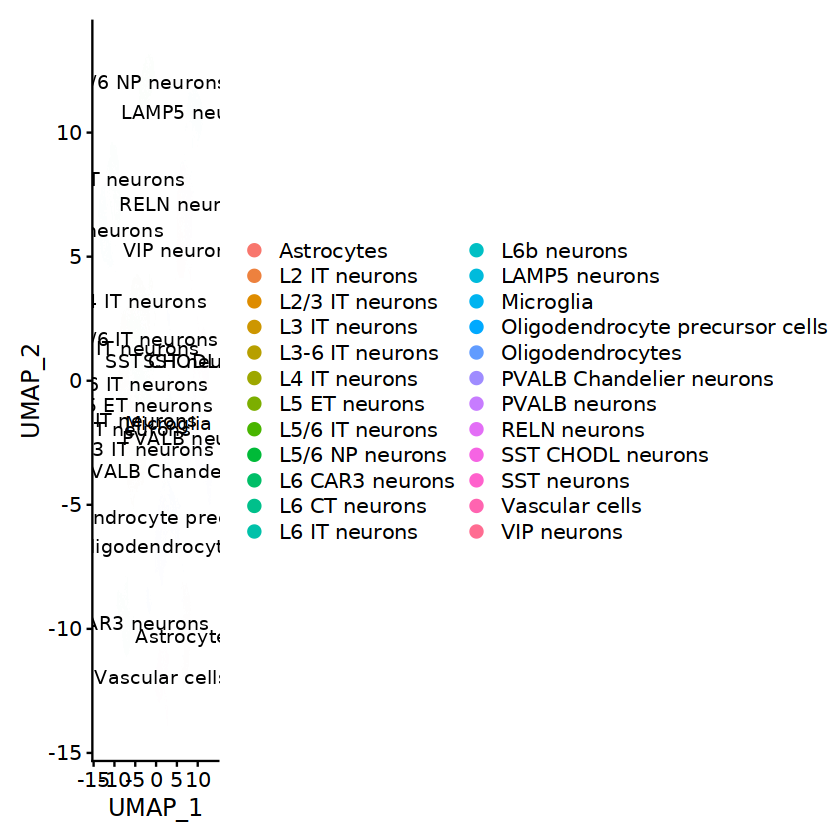

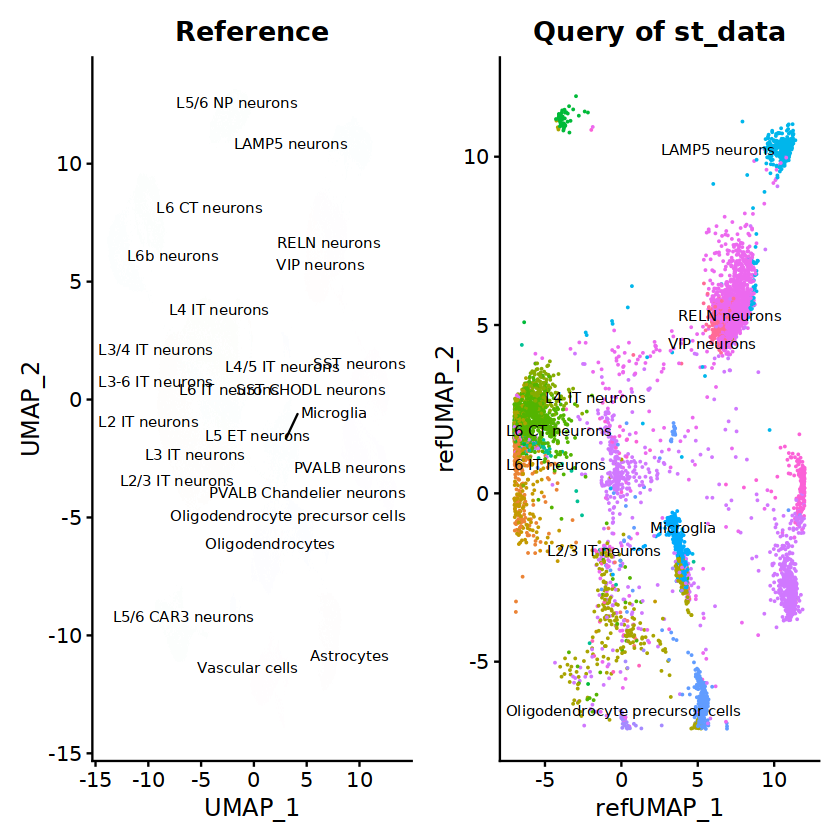

In [6]:
genelist = rownames(sc_data@assays$RNA@scale.data)
#2. find anchor ----
anchors <- FindTransferAnchors(reference = sc_data, query = st_data,features = genelist,
                               dims = 1:20, reference.reduction = "pca")
predictions <- TransferData(anchorset = anchors, refdata = sc_data$subclass.v2,
                            dims = 1:20)
# add metadata
st_data <- AddMetaData(st_data, metadata = predictions)
#3. UMAP projection----
data2 <- RunUMAP(sc_data, dims = 1:25, reduction = "pca", return.model = TRUE)
DimPlot(data2, label=T)
st_data <- MapQuery(anchorset = anchors, reference = data2, query = st_data,
                       #refdata = list(seurat_clusters = "seurat_clusters"),  #可以映射多个标签
                       refdata = list(celltype = "subclass.v4"), 
                       reference.reduction = "pca", 
                       reduction.model = "umap")

p1 <- DimPlot(data2, reduction = "umap", group.by = "subclass.v4", label = TRUE, label.size = 3,
              repel = TRUE) + NoLegend() + ggtitle("Reference")
p2 <- DimPlot(st_data, reduction = "ref.umap", group.by = "predicted.id", label = TRUE,
              label.size = 3, repel = TRUE) + NoLegend() + ggtitle("Query of st_data")+
  xlim(-7,12)+ ylim(-7,12)
p1 + p2

In [ ]:
write.csv(st_data@meta.data,paste0('/data/Seurat_',profile,".cellbin_prct.csv"))